In [3]:
import scanpy as sc
from sklearn.metrics import silhouette_score

ModuleNotFoundError: No module named 'scanpy'

In [ ]:
# Load the Leiden coordinates file
adata_leiden = sc.read_h5ad("./data/bacteria_leiden_coordinates.h5ad")

# Load the MICA coordinates file
adata_mica = sc.read_h5ad("./data/bacteria_mica_coordinates.h5ad")

/home/vasileioubill95/miniconda3/envs/nathan/lib/python3.14/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
print("=== MICA ===")
print(adata_mica)
print(adata_mica.obs.columns.tolist())
print(adata_mica.obs['clusterID'].value_counts())
 
print("\n=== LEIDEN ===")
print(adata_leiden)
print(adata_leiden.obs.columns.tolist())
print(adata_leiden.obs['leiden'].value_counts())
print(adata_leiden.obs['leiden'].value_counts().sort_index())

=== MICA ===
AnnData object with n_obs × n_vars = 7884 × 2853
    obs: 'total_counts', 'sample', 'projectID', 'nUMI', 'nFeature', 'pctMito', 'pctSpikeIn', 'CellID', 'clusterID'
    uns: 'clusterID_colors'
    obsm: 'X_umap'
['total_counts', 'sample', 'projectID', 'nUMI', 'nFeature', 'pctMito', 'pctSpikeIn', 'CellID', 'clusterID']
clusterID
6    2981
4    1427
7     872
2     792
1     681
5     660
3     471
Name: count, dtype: int64

=== LEIDEN ===
AnnData object with n_obs × n_vars = 7884 × 2853
    obs: 'total_counts', 'sample', 'leiden', 'Leiden_Cluster', 'Condition'
    uns: 'leiden', 'leiden_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
['total_counts', 'sample', 'leiden', 'Leiden_Cluster', 'Condition']
leiden
0    5930
1    1361
2     306
3     172
4      68
5      33
6      14
Name: count, dtype: int64
leiden
0    5930
1    1361
2     306
3     172
4      68
5      33
6      14
Name: coun

In [ ]:
# For MICA (clusterID column)
num_mica_clusters = adata_mica.obs['clusterID'].nunique()
print(f"MICA has {num_mica_clusters} clusters.")

# For LEIDEN (leiden column)
num_leiden_clusters = adata_leiden.obs['leiden'].nunique()
print(f"Leiden has {num_leiden_clusters} clusters.")


MICA has 7 clusters.
Leiden has 7 clusters.


Proper 1-to-1 Expression-Based Mapping Profile:
  MICA Cluster 1 uniquely aligns with Leiden Cluster 3 (Spearman rho: 0.628)
  MICA Cluster 2 uniquely aligns with Leiden Cluster 6 (Spearman rho: 0.174)
  MICA Cluster 3 uniquely aligns with Leiden Cluster 1 (Spearman rho: 0.840)
  MICA Cluster 4 uniquely aligns with Leiden Cluster 4 (Spearman rho: 0.643)
  MICA Cluster 5 uniquely aligns with Leiden Cluster 2 (Spearman rho: 0.537)
  MICA Cluster 6 uniquely aligns with Leiden Cluster 0 (Spearman rho: 0.996)
  MICA Cluster 7 uniquely aligns with Leiden Cluster 5 (Spearman rho: 0.451)


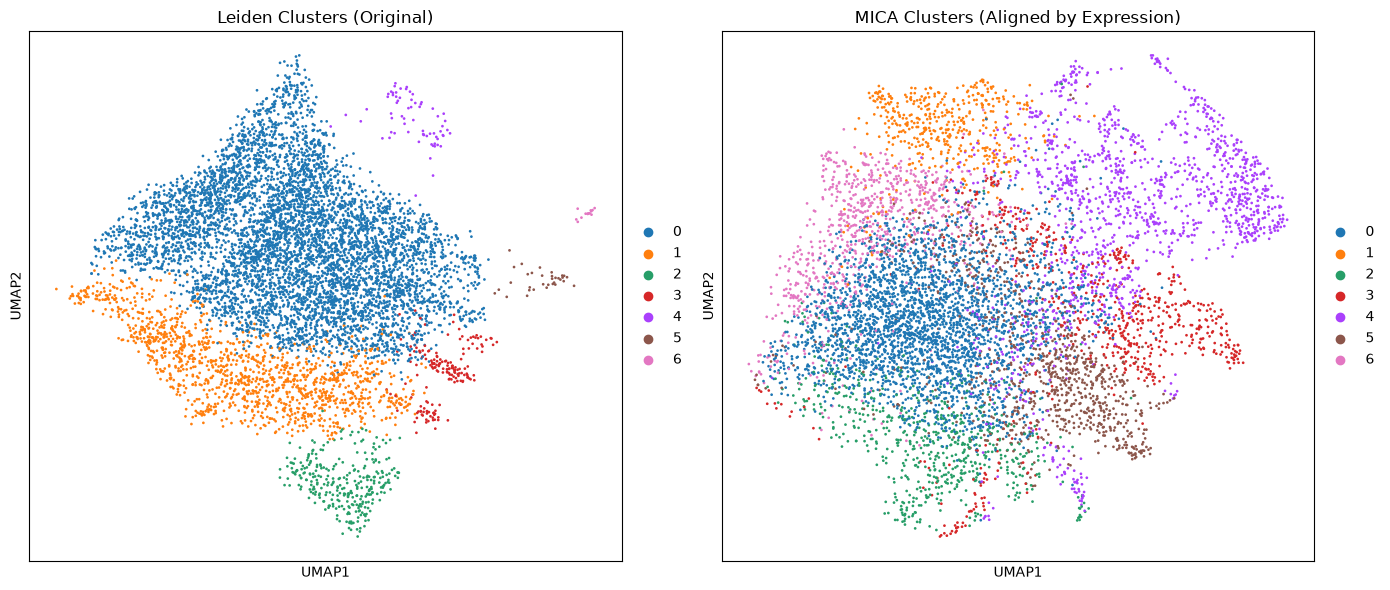

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.optimize import linear_sum_assignment
from scipy.stats import spearmanr

# 1. Safely extract values as raw numpy arrays to prevent axis size expansion
leiden_vals = adata_leiden.obs["leiden"].values
mica_vals = adata_mica.obs["clusterID"].values

# Create a strict 1D boolean mask matching the 7,884 cells
clean_mask = pd.notna(leiden_vals) & pd.notna(mica_vals)

leiden_clean = leiden_vals[clean_mask].astype(str)
mica_clean = mica_vals[clean_mask].astype(str)

# 2. Slice the matrix using the validated 1D mask
if hasattr(adata_leiden.X, "toarray"):
    exp_matrix = adata_leiden.X[clean_mask].toarray()
else:
    exp_matrix = adata_leiden.X[clean_mask]

exp_df = pd.DataFrame(
    exp_matrix,
    index=adata_leiden.obs_names[clean_mask],
    columns=adata_leiden.var_names,
)

# 3. Compute mean expression vectors for every valid cluster
leiden_profiles = exp_df.groupby(leiden_clean, observed=True).mean()
mica_profiles = exp_df.groupby(mica_clean, observed=True).mean()

# 4. Construct a profile Spearman Correlation Matrix
l_labels = sorted(leiden_profiles.index)
m_labels = sorted(mica_profiles.index)
corr_matrix = pd.DataFrame(0.0, index=l_labels, columns=m_labels)

for l_lbl in l_labels:
    for m_lbl in m_labels:
        rho, _ = spearmanr(
            leiden_profiles.loc[l_lbl], mica_profiles.loc[m_lbl]
        )
        corr_matrix.loc[l_lbl, m_lbl] = rho if not np.isnan(rho) else -1.0

# 5. Use the Hungarian Algorithm to guarantee a strict 1-to-1 unique mapping
row_ind, col_ind = linear_sum_assignment(-corr_matrix.values)

best_matches = {}
for r, c in zip(row_ind, col_ind):
    l_c = corr_matrix.index[r]
    m_c = corr_matrix.columns[c]
    best_matches[str(m_c)] = str(l_c)

print("Proper 1-to-1 Expression-Based Mapping Profile:")
for m_c, l_c in sorted(best_matches.items()):
    print(
        f"  MICA Cluster {m_c} uniquely aligns with Leiden Cluster {l_c} (Spearman rho: {corr_matrix.loc[l_c, m_c]:.3f})"
    )

# 6. Apply mapping to a clean ordered categorical slot
aligned_list = [
    best_matches.get(str(x), "0") for x in adata_mica.obs["clusterID"]
]
adata_mica.obs["aligned_mica"] = pd.Categorical(
    aligned_list, categories=[str(i) for i in range(7)], ordered=True
)

# 7. Transfer palette keys
if "leiden_colors" in adata_leiden.uns:
    adata_mica.uns["aligned_mica_colors"] = adata_leiden.uns["leiden_colors"]

# 8. Re-plot the side-by-side comparative graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.umap(
    adata_leiden,
    color="leiden",
    title="Leiden Clusters (Original)",
    ax=axes[0],
    show=False,
)
sc.pl.umap(
    adata_mica,
    color="aligned_mica",
    title="MICA Clusters (Aligned by Expression)",
    ax=axes[1],
    show=False,
)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import adjusted_rand_score

# 1. Extract the clean cell series matching our valid cells filter
leiden_labels = adata_leiden.obs.loc[clean_mask, "leiden"]
mica_original_labels = adata_mica.obs.loc[clean_mask, "clusterID"]
mica_aligned_labels = adata_mica.obs.loc[clean_mask, "aligned_mica"]

# 2. Calculate the ARI scores
ari_mica_vs_aligned = adjusted_rand_score(mica_original_labels, mica_aligned_labels)
ari_leiden_vs_mica = adjusted_rand_score(leiden_labels, mica_aligned_labels)

print("====================================================")
print("           CLUSTERING SIMILARITY SCORES (ARI)       ")
print("====================================================")
print(f"Original MICA vs. Aligned MICA ARI : {ari_mica_vs_aligned:.4f} (Expected: 1.0000)")
print(f"Original Leiden vs. Aligned MICA ARI: {ari_leiden_vs_mica:.4f}")
print("====================================================")


           CLUSTERING SIMILARITY SCORES (ARI)       
Original MICA vs. Aligned MICA ARI : 1.0000 (Expected: 1.0000)
Original Leiden vs. Aligned MICA ARI: 0.1825


In [ ]:
# Compute Silhouette scores in the non-linear UMAP space
umap_coords_leiden = adata_leiden.obsm["X_umap"][clean_mask]
umap_coords_mica = adata_mica.obsm["X_umap"][
    clean_mask
]  # uses MICA's native UMAP

sil_leiden_umap = silhouette_score(
    umap_coords_leiden, leiden_labels, metric="euclidean"
)
sil_mica_umap = silhouette_score(
    umap_coords_mica, mica_aligned_labels, metric="euclidean"
)

print("====================================================")
print("       SILHOUETTE SCORE ANALYSIS (IN UMAP SPACE)    ")
print("====================================================")
print(f"Leiden Clustering UMAP Silhouette Score : {sil_leiden_umap:.4f}")
print(f"Aligned MICA Clustering UMAP Silhouette Score: {sil_mica_umap:.4f}")
print("====================================================")


       SILHOUETTE SCORE ANALYSIS (IN UMAP SPACE)    
Leiden Clustering UMAP Silhouette Score : 0.1513
Aligned MICA Clustering UMAP Silhouette Score: 0.0872


In [ ]:
# ---------------------------------------------------------------------------
# 1. Clean data objects and ensure raw count matrices are normalized
# ---------------------------------------------------------------------------
# Ensure sc.tl.rank_genes_groups uses log-normalized data
for adata in [adata_leiden, adata_mica]:
    if "log1p" not in adata.uns:
        print("Warning: Data might not be log-transformed. Normalizing...")
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)

# ---------------------------------------------------------------------------
# 2. Find Marker Genes for Leiden
# ---------------------------------------------------------------------------
print("Finding marker genes for Leiden Clusters...")
sc.tl.rank_genes_groups(
    adata_leiden, groupby="leiden", method="wilcoxon", key_added="rank_leiden"
)

# ---------------------------------------------------------------------------
# 3. Find Marker Genes for Aligned MICA
# ---------------------------------------------------------------------------
print("Finding marker genes for Aligned MICA Clusters...")
sc.tl.rank_genes_groups(
    adata_mica,
    groupby="aligned_mica",
    method="wilcoxon",
    key_added="rank_mica",
)

# ---------------------------------------------------------------------------
# 4. Compare the Number of High-Quality Markers per Cluster
# ---------------------------------------------------------------------------
# We look for genes with logFoldChange > 1.0 and adjusted p-value < 0.05
print("\n=== MARKER GENE QUALITY COMPARISON ===")
print(f"{'Cluster':<10}{'Leiden High-Qual Markers':<26}{'MICA High-Qual Markers'}")
print("-" * 65)

for cluster_idx in sorted(adata_leiden.obs["leiden"].unique().astype(str)):
    # Leiden filters
    df_leiden = sc.get.rank_genes_groups_df(
        adata_leiden, group=cluster_idx, key="rank_leiden"
    )
    leiden_count = len(
        df_leiden[(df_leiden["logfoldchanges"] > 1.0) & (df_leiden["pvals_adj"] < 0.05)]
    )

    # MICA filters
    df_mica = sc.get.rank_genes_groups_df(
        adata_mica, group=cluster_idx, key="rank_mica"
    )
    mica_count = len(
        df_mica[(df_mica["logfoldchanges"] > 1.0) & (df_mica["pvals_adj"] < 0.05)]
    )

    print(f"{cluster_idx:<10}{leiden_count:<26}{mica_count}")


Finding marker genes for Leiden Clusters...
Finding marker genes for Aligned MICA Clusters...

=== MARKER GENE QUALITY COMPARISON ===
Cluster   Leiden High-Qual Markers  MICA High-Qual Markers
-----------------------------------------------------------------
0         166                       704
1         0                         5
2         0                         4
3         2                         2
4         124                       0
5         73                        4
6         76                        7


In [ ]:
import io
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scanpy as sc
import seaborn as sns

# ---------------------------------------------------------------------------
# CONFIGURATION - STABLE BACTERIAL ENDPOINT MATRIX
# ---------------------------------------------------------------------------
STAPH_TAXID = 1280  # S. aureus Core TaxID
STRING_API_URL = "https://string-db.org/api"


def get_string_metrics_and_enrichment(genes_list, run_name):
    """Queries STRING API to calculate network metrics (nodes, edges) and pathway enrichment."""
    print(f"\n--- [Processing {run_name}] ---")
    print(f"Submitting {len(genes_list)} native symbols. Sample: {genes_list[:10]}")

    payload = {
        "identifiers": "\n".join(genes_list),
        "species": STAPH_TAXID,
        "caller_identity": "staph_bacterial_native_sc",
    }

    # Initialize empty tracking defaults
    num_nodes = 0
    num_edges = 0
    enrich_df = pd.DataFrame()

    try:
        # Step 1: Query the Interaction Network to extract edge counts
        network_resp = requests.post(
            f"{STRING_API_URL}/tsv/network", data=payload
        )
        if network_resp.status_code == 200 and network_resp.text.strip():
            network_df = pd.read_csv(io.StringIO(network_resp.text), sep="\t")
            if not network_df.empty and "stringId_A" in network_df.columns:
                # Nodes = number of unique mapped proteins connected in the network
                unique_nodes = set(network_df["stringId_A"]).union(
                    set(network_df["stringId_B"])
                )
                num_nodes = len(unique_nodes)
                num_edges = len(network_df)

        print(f"✔ Network Statistics: {num_nodes} Nodes, {num_edges} Edges found.")

        # Step 2: Query the Functional Overrepresentation Enrichment Backend
        enrich_resp = requests.post(
            f"{STRING_API_URL}/tsv/enrichment", data=payload
        )
        if enrich_resp.status_code == 200 and enrich_resp.text.strip():
            enrich_df = pd.read_csv(io.StringIO(enrich_resp.text), sep="\t")
            if not enrich_df.empty and "fdr" in enrich_df.columns:
                enrich_df["fdr"] = pd.to_numeric(
                    enrich_df["fdr"], errors="coerce"
                )
                enrich_df = enrich_df.dropna(subset=["fdr"])
                print(f"✔ Successfully mapped {len(enrich_df)} metabolic pathways.")

        return enrich_df, num_nodes, num_edges

    except Exception as e:
        print(f"❌ Server connection failure: {e}")
        return pd.DataFrame(), 0, 0


def extract_all_explainable_genes(adata, rank_key):
    """Extracts ALL statistically significant genes, keeping native bacterial formats."""
    df = sc.get.rank_genes_groups_df(adata, group="0", key=rank_key)

    # Filter strictly by your differential expression threshold criteria
    df_filtered = df[(df["logfoldchanges"] > 1.0) & (df["pvals_adj"] < 0.05)]
    raw_list = df_filtered["names"].tolist()

    # Words to ignore from broken annotation description blocks
    blacklist = {
        "protein",
        "hypothetical",
        "putative",
        "subunit",
        "rna",
        "domain",
        "family",
        "type",
        "energy",
        "nickel",
        "signal",
        "antiporter",
        "component",
    }

    clean_list = []
    for g in raw_list:
        tokens = re.split(r"[\s_,-]+", str(g).strip())
        valid_token = None

        for token in tokens:
            if token.lower() not in blacklist and len(token) >= 3:
                valid_token = token
                break

        if not valid_token and tokens:
            fallback = [t for t in tokens if t.lower() not in blacklist]
            if fallback:
                valid_token = (
                    fallback[0] if isinstance(fallback, list) else fallback
                )

        if valid_token and valid_token not in clean_list:
            clean_list.append(str(valid_token))

    return clean_list


# 1. EXTRACT NATIVE BACTERIAL GENES
print("Extracting all explainable markers for Cluster 0...")
leiden_all = extract_all_explainable_genes(adata_leiden, "rank_leiden")
mica_all = extract_all_explainable_genes(adata_mica, "rank_mica")

# 2. RUN PIPELINE TRACKS (Fetches enrichment AND edge metrics simultaneously)
leiden_enrich, leiden_nodes, leiden_edges = get_string_metrics_and_enrichment(
    leiden_all, "Leiden Cluster 0"
)
mica_enrich, mica_nodes, mica_edges = get_string_metrics_and_enrichment(
    mica_all, "MICA Cluster 0"
)

# ---------------------------------------------------------------------------
# 3. VERTICAL 2x1 PUBLICATION BARPLOTS WITH NETWORK METRICS
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 16))
datasets = [
    (
        leiden_enrich,
        "Leiden Cluster 0",
        leiden_nodes,
        leiden_edges,
        "Blues_r",
    ),
    (mica_enrich, "MICA Cluster 0", "MICA Cluster 0", mica_nodes, mica_edges, "Oranges_r"),
]

for idx, data_tuple in enumerate(datasets):
    # Handle unpacking variations automatically based on the sequence block length
    if len(data_tuple) == 5:
        df, title, nodes, edges, cmap = data_tuple
    else:
        df, _, title, nodes, edges, cmap = data_tuple

    if df.empty:
        axes[idx].text(
            0.5,
            0.5,
            "No Enrichment Data Found via API.",
            ha="center",
            va="center",
            fontsize=12,
            color="red",
        )
        axes[idx].set_title(title, weight="bold")
        continue

    # Filter out weak background noise
    sig_df = df[df["fdr"] < 0.05].copy()
    if sig_df.empty:
        axes[idx].text(
            0.5,
            0.5,
            "No pathways passed the strict FDR < 0.05 threshold.",
            ha="center",
            va="center",
            fontsize=12,
        )
        axes[idx].set_title(title, weight="bold")
        continue

    sig_df["-log10_FDR"] = -np.log10(sig_df["fdr"])
    top_10 = sig_df.sort_values("fdr").head(10)

    # Plot horizontal bar charts representing impact scale
    sns.barplot(
        data=top_10,
        x="-log10_FDR",
        y="description",
        hue="description",
        palette=cmap,
        edgecolor="black",
        legend=False,
        ax=axes[idx],
    )

    axes[idx].axvline(-np.log10(0.05), color="red", linestyle="--", alpha=0.7)

    # DYNAMIC HEADING: Embeds the Node and Edge numbers calculated straight from STRING-db
    axes[idx].set_title(
        f"Top Pathways: {title} ({nodes} Connected Proteins, {edges} Interaction Edges)",
        fontsize=13,
        weight="bold",
    )
    axes[idx].set_xlabel("-log10(False Discovery Rate)", fontsize=11)
    axes[idx].set_ylabel("")
    axes[idx].grid(True, linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'scanpy'